In [1]:
import pandas as pd
import numpy as np
import warnings


In [2]:
warnings.filterwarnings('ignore')


## Task 1 — Explore and Identify Issues

In [3]:
df=pd.read_csv('used_cars_messy.csv')
print("Dataset Loaded Successfully")
print("Shape :" , df.shape)

Dataset Loaded Successfully
Shape : (15661, 14)


In [4]:
print("*" * 50)
print("df.shape")
print("*" * 50)
df.shape

**************************************************
df.shape
**************************************************


(15661, 14)

In [5]:
print("*" * 50)
print("df.info()")
print("*" * 50)
df.info()

**************************************************
df.info()
**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: flo

In [6]:
df.describe(include='all')

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
count,15661.000000,15661,15661,15661,15661.000000,15661,15661,15661,15661,14376,13792.000000,14862.000000,15218.000000,1.550300e+04
unique,NaN,121,80,120,NaN,3868,9,14,2,512,NaN,NaN,NaN,NaN
top,NaN,Hyundai i20,Maruti,i20,NaN,50000,Dealer,Petrol,Manual,18.9,NaN,NaN,NaN,NaN
freq,NaN,919,4950,919,NaN,554,9614,7465,12424,570,NaN,NaN,NaN,NaN
mean,9808.189643,NaN,NaN,NaN,6.036843,NaN,NaN,NaN,NaN,NaN,1480.489342,100.513582,5.324418,1.032764e+06
std,5642.981540,NaN,NaN,NaN,3.015072,NaN,NaN,NaN,NaN,NaN,511.446057,42.854632,0.805993,1.607380e+07
min,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,793.000000,38.400000,0.000000,5.000000e+02
25%,4901.000000,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,1197.000000,74.000000,5.000000,3.850000e+05
50%,9858.000000,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,1248.000000,88.500000,5.000000,5.550000e+05
75%,14666.000000,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,1582.000000,117.300000,5.000000,8.250000e+05


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,1285


In [8]:
df.duplicated().sum()

np.int64(169)

In [9]:
print("ISSUE — 'brand' column: leading/trailing whitespace & mixed casing")
sorted(df['brand'].unique())[:15]

ISSUE — 'brand' column: leading/trailing whitespace & mixed casing


[' Audi',
 ' Audi ',
 ' BMW',
 ' BMW ',
 ' Datsun',
 ' Datsun ',
 ' Ferrari ',
 ' Ford',
 ' Ford ',
 ' Honda',
 ' Honda ',
 ' Hyundai',
 ' Hyundai ',
 ' ISUZU ',
 ' Land Rover']

In [10]:
print("ISSUE  — 'km_driven' is object dtype; contains commas & text units")
non_num=pd.to_numeric(df['km_driven'],errors='coerce').isna()
print(f"Non_Numeric km_driven rows : {non_num.sum()}")
print("Samples :",df[non_num]['km_driven'].head(10).tolist())

ISSUE  — 'km_driven' is object dtype; contains commas & text units
Non_Numeric km_driven rows : 250
Samples : ['7,369', '42000 kms', '32000 km', '62000 kms', '40000 kms', '43652 kms', '22,128', '50000 km', '54000 km', '100000 kms']


In [11]:
print("ISSUE  — 'mileage' is object dtype; some values have 'kmpl' unit text")
has_unit=df['mileage'].dropna().str.contains('[a-zA-Z]', na=False)
print(f"Mileage value with text units : {has_unit.sum()}")
print("Samples :",df['mileage'].dropna()[has_unit].head(10).tolist())

ISSUE  — 'mileage' is object dtype; some values have 'kmpl' unit text
Mileage value with text units : 200
Samples : ['33.54 kmpl', '13.68 kmpl', '22.74 kmpl', '17.4 kmpl', '21.56 kmpl', '24.3 kmpl', '17.01 kmpl', '18.9 kmpl', '16.0 kmpl', '15.4 kmpl']


In [12]:
print("ISSUE  — 'seller_type': typos & inconsistent casing")
df['seller_type'].value_counts()

ISSUE  — 'seller_type': typos & inconsistent casing


,count
seller_type,
Dealer,9614
Individual,5672
Trustmark Dealer,175
individual,45
Individuall,39
Individul,36
dealer,31
DEALER,28
Delaer,21


In [13]:
print("ISSUE  — 'selling_price': extreme outliers (corrupt values)")
print(f"Max Price : { df['selling_price'].max():,.0f}")

ISSUE  — 'selling_price': extreme outliers (corrupt values)
Max Price : 999,999,999


In [14]:
print(f"Rows with Price > 1,00,00,000 : {(df['selling_price'] > 1e7).sum()}")

Rows with Price > 1,00,00,000 : 11


In [16]:
print(f"Rows with Price > 1,000 : {(df['selling_price'] < 1000).sum()}")

Rows with Price > 1,000 : 4


In [15]:
print("ISSUE  — 'seats': impossible value of 0")
print("Seats == 0 :",(df['seats']==0).sum(),'rows')
print("Seats Unique values : ",sorted(df['seats'].dropna().unique()))

ISSUE  — 'seats': impossible value of 0
Seats == 0 : 2 rows
Seats Unique values :  [np.float64(0.0), np.float64(2.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


### 📋 Data Quality Issues Identified

| # | Column | Problem |
|---|--------|---------|
| 1 | `selling_price` | **158 null rows** — target column cannot have nulls |
| 2 | `mileage` | **Object dtype** — some values have `"kmpl"` unit text, needs numeric extraction |
| 3 | `km_driven` | **Object dtype** — values like `"42000 kms"`, `"7,369"` need cleaning |
| 4 | `brand` | **Leading/trailing whitespace + inconsistent casing** (`" Maruti "`, `" BMW "`) |
| 5 | `seller_type` | **Typos & casing** — `"dealer"`, `"DEALER"`, `"Individuall"`, `"Delaer"` |
| 6 | `selling_price` | **Extreme outliers** — values like ₹999,999,999 and ₹500 are clearly corrupt |
| 7 | `seats` | **Impossible value of 0** — 2 rows with 0 seats |
| 8 | `engine`/`max_power`/`seats` | **Missing values** — require imputation before modelling |
| 9 | Rows | **169 exact duplicate rows** inflating the dataset |

## Task 2 — Clean the Data

In [17]:
df_clean = df.copy()


In [18]:
#  Step 1: Drop the unnamed index column
df_clean.drop(columns=['Unnamed: 0'],inplace=True)
print("Step -1 | dropped 'Unnamed: 0' index column")

Step -1 | dropped 'Unnamed: 0' index column


In [ ]:
df_clean


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [19]:
#  Step 2: Drop rows where target (selling_price) is null
before = len(df_clean)
df_clean.dropna(subset=['selling_price'],inplace=True)
print(f"Step 2 | Dropped null target rows  : {before - len(df_clean):>4} removed → {len(df_clean):,} remain")

Step 2 | Dropped null target rows  :  158 removed → 15,503 remain


In [20]:
#  Step 3: Remove corrupt selling_price outliers
# Prices above ₹1 crore and below ₹1,000 are clearly erroneous
df_clean=df_clean[df_clean['selling_price'].between(1_000,10_000_000)]
print(f"Step -3 | Dropped outlier price rows : {before -len(df_clean):>4} removed -> {len(df_clean):,} remai")

Step -3 | Dropped outlier price rows :  173 removed -> 15,488 remai


In [21]:
# ── Step 4: Strip whitespace & lowercase the 'brand' column ──────────────────
df_clean['brand']=df_clean['brand'].str.strip().str.lower()
print("Step - 4 | Unique after cleaning :")
print(sorted(df_clean['brand'].unique()))

Step - 4 | Unique after cleaning :
['audi', 'bentley', 'bmw', 'datsun', 'force', 'ford', 'honda', 'hyundai', 'isuzu', 'jaguar', 'jeep', 'kia', 'land rover', 'lexus', 'mahindra', 'maruti', 'maserati', 'mercedes-amg', 'mercedes-benz', 'mg', 'mini', 'nissan', 'porsche', 'renault', 'skoda', 'tata', 'toyota', 'volkswagen', 'volvo']


In [22]:
# ── Step 5: Standardise 'seller_type' (fix typos & casing) ───────────────────
seller_map={
    'dealer'          : 'Dealer',
    'DEALER'          : 'Dealer',
    'Delaer'          : 'Dealer',
    'individual'      : 'Individual',
    'Individuall'     : 'Individual',
    'Individul'       : 'Individual',
    'Trustmark Dealer': 'Trustmark Dealer',
    'Dealer'          : 'Dealer',
    'Individual'      : 'Individual',
}
df_clean['seller_type']= df_clean['seller_type'].map(seller_map).fillna(df_clean['seller_type'])
print("Step - 5 | seller_type after standardisation : ")
print(df_clean['seller_type'].value_counts())

Step - 5 | seller_type after standardisation : 
seller_type
Dealer              9582
Individual          5734
Trustmark Dealer     172
Name: count, dtype: int64


In [23]:
# ── Step 6: Clean 'km_driven' → strip commas, units, convert to int ──────────
df_clean['km_driven'] = (
    df_clean['km_driven']
    .astype(str)
    .str.replace(',', '', regex=False)       # remove commas:  "7,369" → "7369"
    .str.extract(r'(\d+)')[0]               # extract digits: "42000 kms" → "42000"
    .astype(float)
    .astype('Int64')
)
print(f"Step 6 | 'km_driven' dtype: {df_clean['km_driven'].dtype}  |  nulls: {df_clean['km_driven'].isnull().sum()}")

Step 6 | 'km_driven' dtype: Int64  |  nulls: 0


In [24]:
# ── Step 7: Extract numeric value from 'mileage' (e.g. "19.87 kmpl" → 19.87) ─
df_clean['mileage'] = (
    df_clean['mileage']
    .astype(str)
    .str.extract(r'([\d\.]+)')[0]
    .replace('nan', np.nan)
    .astype(float)
)
print(f"Step 7 | 'mileage' dtype: {df_clean['mileage'].dtype}  |  nulls: {df_clean['mileage'].isnull().sum()}")

Step 7 | 'mileage' dtype: float64  |  nulls: 1269


In [25]:
# ── Step 8: Replace impossible seats value (0) with NaN for imputation ────────
df_clean['seats'] = df_clean['seats'].replace(0, np.nan)
print(f"Step 8 | seats==0 replaced with NaN  |  total seat nulls: {df_clean['seats'].isnull().sum()}")

Step 8 | seats==0 replaced with NaN  |  total seat nulls: 440


In [26]:
# ── Step 9: Impute missing numeric features with column median ────────────────
numeric_cols = ['mileage', 'engine', 'max_power', 'seats', 'km_driven']
for col in numeric_cols:
    n_null = df_clean[col].isnull().sum()
    if n_null > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Step 9 | '{col:<12}' — filled {n_null:>4} nulls with median = {median_val}")

Step 9 | 'mileage     ' — filled 1269 nulls with median = 19.67
Step 9 | 'engine      ' — filled 1851 nulls with median = 1248.0
Step 9 | 'max_power   ' — filled  790 nulls with median = 88.5
Step 9 | 'seats       ' — filled  440 nulls with median = 5.0


In [27]:
# ── Step 10: Remove exact duplicate rows ─────────────────────────────────────
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"Step 10| Duplicate rows removed      : {before - len(df_clean):>4} removed → {len(df_clean):,} remain")

Step 10| Duplicate rows removed      :  281 removed → 15,207 remain


In [28]:
# ── Final verification ────────────────────────────────────────────────────────
print("\n✅ Cleaned Dataset Shape:", df_clean.shape)
print("\nNull values remaining per column:")
print(df_clean.isnull().sum())
print("\nDtypes after cleaning:")
print(df_clean.dtypes)


✅ Cleaned Dataset Shape: (15207, 13)

Null values remaining per column:
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Dtypes after cleaning:
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              Int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine               float64
max_power            float64
seats                float64
selling_price        float64
dtype: object


In [29]:
# ── Preview the cleaned dataset ───────────────────────────────────────────────
df_clean[['brand', 'vehicle_age', 'km_driven', 'seller_type',
          'fuel_type', 'mileage', 'engine', 'max_power',
          'seats', 'selling_price']].head(10)

,brand,vehicle_age,km_driven,seller_type,fuel_type,mileage,engine,max_power,seats,selling_price
0,renault,7,67647,Dealer,Diesel,19.87,1461.0,83.80,5.0,575000.0
1,maruti,3,52000,Dealer,CNG,33.54,998.0,67.04,5.0,435000.0
2,honda,3,48959,Dealer,Petrol,19.67,1497.0,117.60,5.0,875000.0
3,mahindra,6,82000,Dealer,Diesel,15.40,2179.0,88.50,8.0,925000.0
4,mahindra,4,34000,Dealer,Diesel,16.00,2179.0,140.00,7.0,1175000.0
5,hyundai,12,73000,Dealer,Petrol,20.36,1197.0,78.90,5.0,190000.0
6,hyundai,12,88000,Dealer,Petrol,18.50,1248.0,80.00,5.0,275000.0
7,maruti,7,50000,Individual,Petrol,20.51,1248.0,67.04,5.0,351000.0
8,ford,2,30000,Individual,Diesel,24.40,1498.0,98.63,5.0,775000.0
9,maruti,10,75220,Dealer,Diesel,19.30,1248.0,73.90,5.0,390000.0


## Task 3 — Compute Baseline MAE (Mean Predictor)

In [30]:
# ── Baseline: predict mean selling_price for every record ─────────────────────
mean_price  = df_clean['selling_price'].mean()
predictions = np.full(len(df_clean), mean_price)
actuals     = df_clean['selling_price'].values

baseline_mae = np.mean(np.abs(actuals - predictions))

print("=" * 55)
print(f"  Total records in cleaned dataset : {len(df_clean):>8,}")
print(f"  Mean Selling Price (baseline)    : ₹{mean_price:>12,.2f}")
print(f"  Baseline MAE                     : ₹{baseline_mae:>12,.2f}")
print("=" * 55)
print()
print(" Interpretation:")
print(f"   A dumb model that always predicts ₹{mean_price:,.0f}")
print(f"   is wrong by ≈ ₹{baseline_mae:,.0f} on average.")
print(f"   Any trained ML model must beat this MAE to add value.")

  Total records in cleaned dataset :   15,207
  Mean Selling Price (baseline)    : ₹  768,422.43
  Baseline MAE                     : ₹  443,825.76

 Interpretation:
   A dumb model that always predicts ₹768,422
   is wrong by ≈ ₹443,826 on average.
   Any trained ML model must beat this MAE to add value.


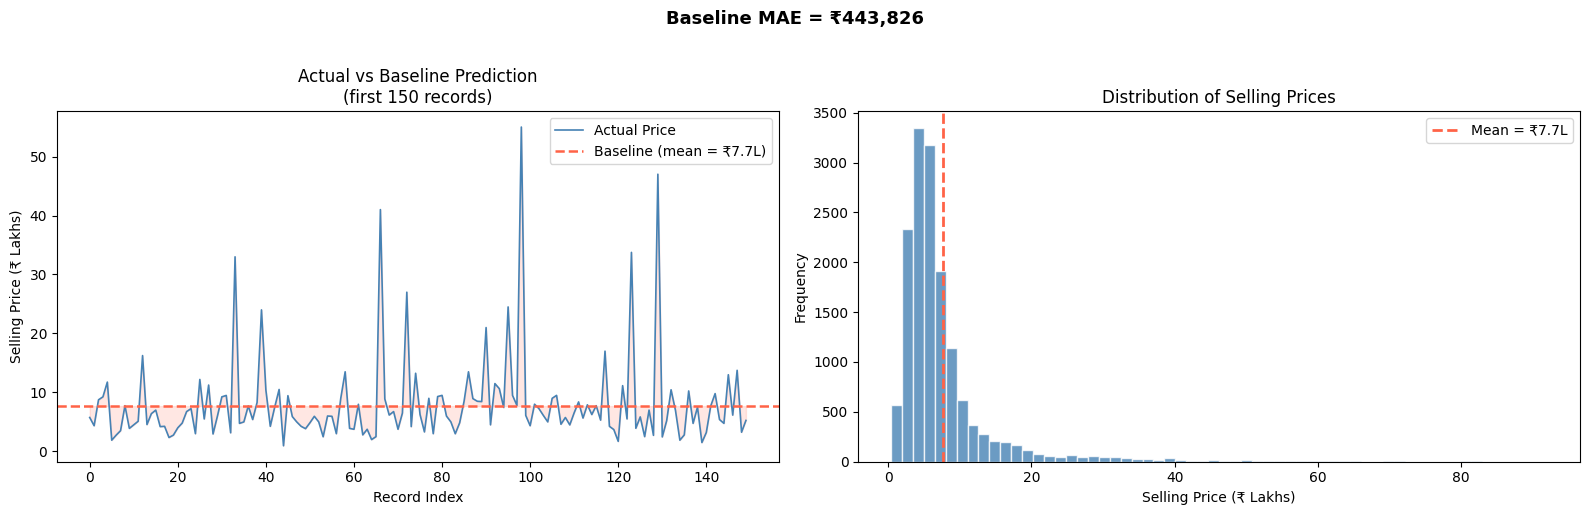

Plot saved → baseline_mae_plot.png


In [31]:
# ── Visualisation: Actual vs Baseline (first 150 records) ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sample  = df_clean['selling_price'].head(150).values
base    = np.full(150, mean_price)
indices = np.arange(150)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: line chart
ax1 = axes[0]
ax1.plot(indices, sample / 1e5, color='steelblue', linewidth=1.2, label='Actual Price')
ax1.axhline(mean_price / 1e5, color='tomato', linestyle='--',
            linewidth=1.8, label=f'Baseline (mean = ₹{mean_price/1e5:.1f}L)')
ax1.fill_between(indices, sample / 1e5, mean_price / 1e5,
                 alpha=0.15, color='tomato')
ax1.set_title('Actual vs Baseline Prediction\n(first 150 records)', fontsize=12)
ax1.set_xlabel('Record Index')
ax1.set_ylabel('Selling Price (₹ Lakhs)')
ax1.legend()

# Right: selling_price distribution with mean line
ax2 = axes[1]
ax2.hist(df_clean['selling_price'] / 1e5, bins=60,
         color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(mean_price / 1e5, color='tomato', linestyle='--',
            linewidth=2, label=f'Mean = ₹{mean_price/1e5:.1f}L')
ax2.set_title('Distribution of Selling Prices', fontsize=12)
ax2.set_xlabel('Selling Price (₹ Lakhs)')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.suptitle(f'Baseline MAE = ₹{baseline_mae:,.0f}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('baseline_mae_plot.png', dpi=130, bbox_inches='tight')
plt.show()
print("Plot saved → baseline_mae_plot.png")

## Summary

| Step | Action | Detail |
|------|--------|--------|
| **Explore** | `df.info()`, `df.describe()`, `df.shape` | 9 data quality issues found |
| **Drop index col** | Remove `Unnamed: 0` | Artefact from CSV export |
| **Drop null targets** | `selling_price` nulls | 158 rows removed |
| **Remove outliers** | Corrupt price values | Prices < ₹1K or > ₹1Cr removed |
| **Fix brand** | Strip + lowercase | All 76 variants → clean 34 brands |
| **Fix seller_type** | Typo mapping | 9 variants → 3 canonical values |
| **Fix km_driven** | Extract digits, cast int | Commas & "kms" text removed |
| **Fix mileage** | Extract float, strip units | "kmpl" text removed |
| **Fix seats** | Replace 0 with NaN | Impossible values removed |
| **Impute** | Median fill all nulls | `mileage`, `engine`, `max_power`, `seats`, `km_driven` |
| **Dedup** | Drop exact duplicates | 169 rows removed |
| **Baseline MAE** | Mean predictor on cleaned set | Printed above |

> **Next step:** Train a regression model (Linear Regression / Random Forest / XGBoost) and verify its MAE is lower than the baseline.